# Tratamento de Dados Ausentes

In [ ]:
import pandas as pd
import numpy as np

path = r'C:\Users\Luca\Documents\git hub\3° Periodo\Data Mining e Graph Mining\churn-prediction-data-mining\archive\telecom_churn_synthetic.csv'
df = pd.read_csv(path)

print(f"Dimensão original: {df.shape}")

# Identificação de Valores Nulos
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

summary_missing = pd.DataFrame({
    'Valores Nulos': missing_values,
    'Porcentagem (%)': missing_percent
}).sort_values(by='Porcentagem (%)', ascending=False)

print("\n--- Resumo de Dados Ausentes ---")
print(summary_missing[summary_missing['Valores Nulos'] > 0])

# Aplicação de Imputação Adequada

# Tratamento para 'total_charges' 
df['total_charges'] = pd.to_numeric(df['total_charges'], errors='coerce')

# Decisão: Usar Mediana para numéricos para evitar influência de outliers
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"-> Imputada MEDIANA em: {col}")

# Decisão: Usar Moda para categóricos (Manter a consistência da categoria mais frequente)
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"-> Imputada MODA em: {col}")

print(f"\nTotal de nulos após tratamento: {df.isnull().sum().sum()}")

Dimensão original: (6000, 27)

--- Resumo de Dados Ausentes ---
                   Valores Nulos  Porcentagem (%)
total_charges                 74         1.233333
avg_download_mbps             46         0.766667
-> Imputada MEDIANA em: total_charges
-> Imputada MEDIANA em: avg_download_mbps

Total de nulos após tratamento: 0


In [ ]:
# Padronização de nomes de colunas
# Transformar em minúsculas e substituir espaços por underscores (boa prática de Python)
df.columns = df.columns.str.lower().str.replace(' ', '_')
print("Colunas padronizadas:")
print(df.columns.tolist())

# Remoção de Duplicatas
duplicates_count = df.duplicated().sum()
if duplicates_count > 0:
    df.drop_duplicates(inplace=True)
    print(f"\n-> {duplicates_count} duplicatas removidas.")
else:
    print("\n-> Nenhuma duplicata encontrada.")

# Correção de Inconsistências e Tipagem
# O customer_id não ajuda na predição e pode causar ruído, vamos removê-lo se ainda estiver presente
if 'customer_id' in df.columns:
    df.drop('customer_id', axis=1, inplace=True)
    print("-> Coluna 'customer_id' removida.")

# Garantir que a variável alvo 'churn' seja inteira (0 ou 1)
df['churn'] = df['churn'].astype(int)

# Verificação de Tipagem Final
print("\nTipagem das colunas após limpeza:")
print(df.dtypes)

print(f"\nDimensão atual do dataset: {df.shape}")

Colunas padronizadas:
['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents', 'tenure_months', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method', 'monthly_charges', 'total_charges', 'complaints_last_3m', 'outages_last_3m', 'avg_download_mbps', 'late_payments_last_6m', 'promo_active', 'discount_pct', 'churn']

-> Nenhuma duplicata encontrada.
-> Coluna 'customer_id' removida.

Tipagem das colunas após limpeza:
gender                    object
senior_citizen             int64
partner                   object
dependents                object
tenure_months              int64
phone_service             object
multiple_lines            object
internet_service          object
online_security           object
online_backup             object
device_protection         object
tech_support              object
streaming_tv  

# Exploração de Dados

C:\Users\Luca\AppData\Local\Temp\ipykernel_12876\264287935.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='churn', data=df, palette='viridis')


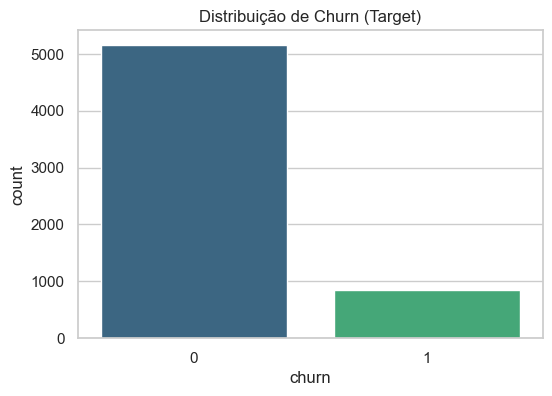

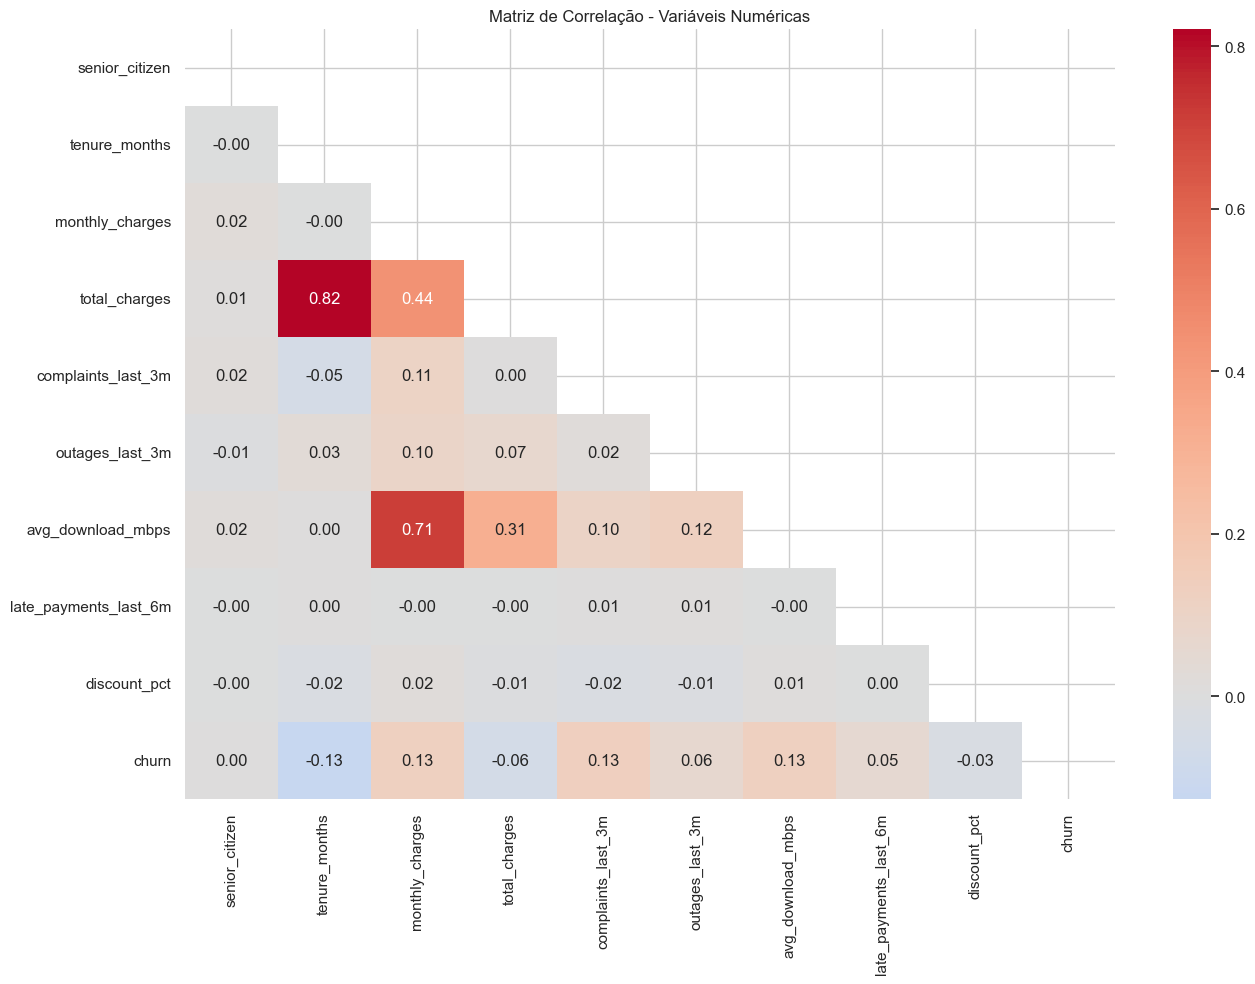

C:\Users\Luca\AppData\Local\Temp\ipykernel_12876\264287935.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churn', y=col, data=df, ax=axes[i], palette='Set2')
C:\Users\Luca\AppData\Local\Temp\ipykernel_12876\264287935.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churn', y=col, data=df, ax=axes[i], palette='Set2')
C:\Users\Luca\AppData\Local\Temp\ipykernel_12876\264287935.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churn', y=col, data=df, ax=axes[i], palette='Set2')
C:\Users\Luca\AppData\Local\Temp\ipykernel_128

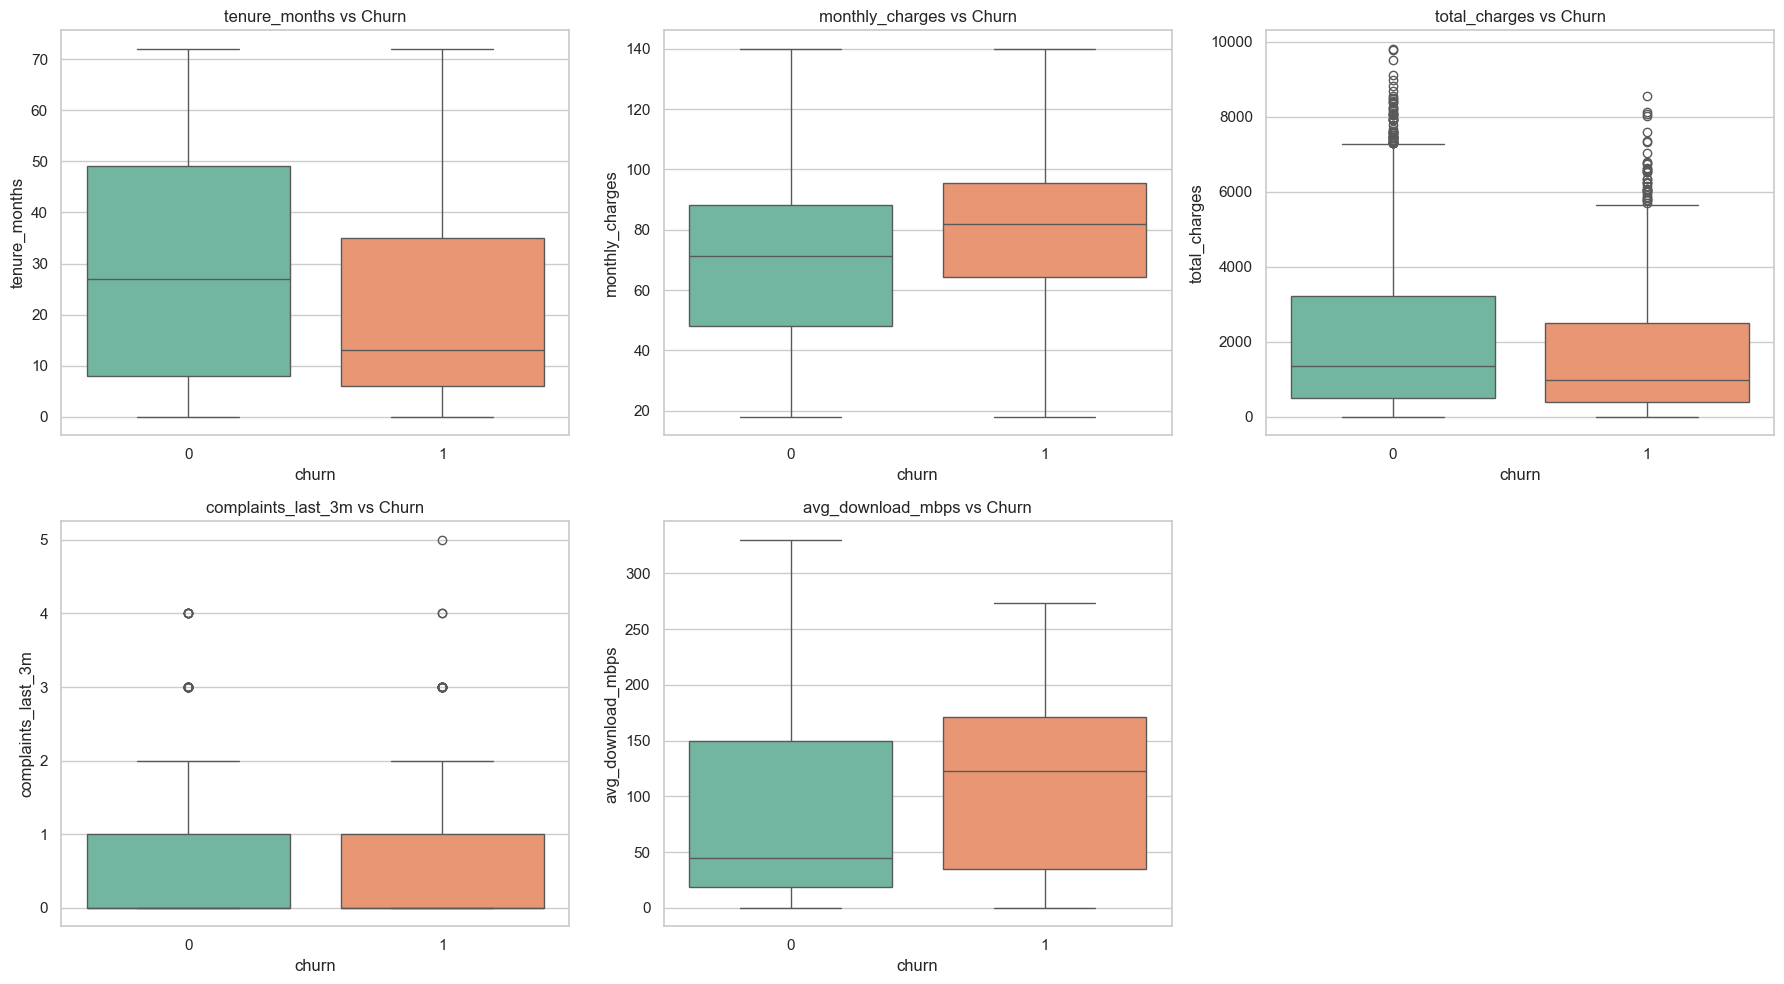

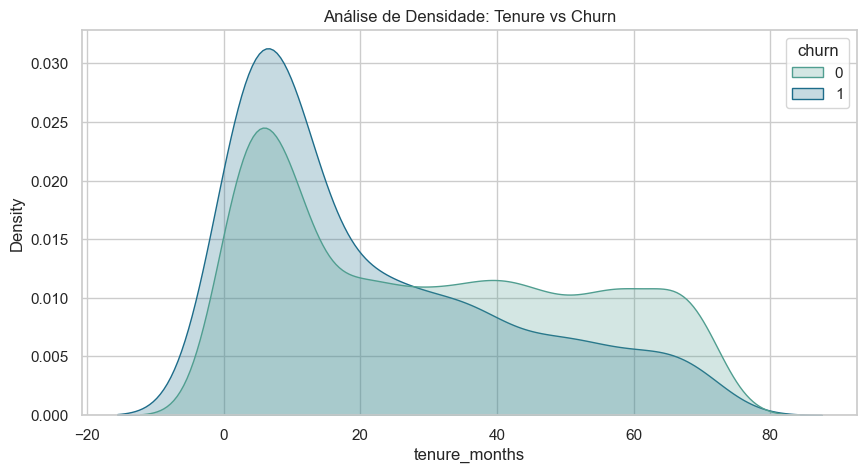


✅ Todos os gráficos foram salvos em: C:\Users\Luca\Documents\git hub\3° Periodo\Data Mining e Graph Mining\regressão-logistica\graficos_prepracao_csv


In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

path_graficos = r'C:\Users\Luca\Documents\git hub\3° Periodo\Data Mining e Graph Mining\churn-prediction-data-mining\graficos_preparation_csv'

if not os.path.exists(path_graficos):
    os.makedirs(path_graficos)
    print(f"-> Pasta criada: {path_graficos}")

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Distribuição da Variável Alvo 
plt.figure(figsize=(6, 4))
sns.countplot(x='churn', data=df, palette='viridis')
plt.title('Distribuição de Churn (Target)')
plt.savefig(os.path.join(path_graficos, '01_distribuicao_churn.png'))
plt.show()

# Matriz de Correlação 
num_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(15, 10))
mask = np.triu(np.ones_like(num_df.corr(), dtype=bool))
sns.heatmap(num_df.corr(), mask=mask, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Matriz de Correlação - Variáveis Numéricas')
plt.savefig(os.path.join(path_graficos, '02_matriz_correlacao.png'))
plt.show()

# Boxplots de Separabilidade 
features_analise = ['tenure_months', 'monthly_charges', 'total_charges', 'complaints_last_3m', 'avg_download_mbps']
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(features_analise):
    sns.boxplot(x='churn', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs Churn')

# Remover o último eixo vazio 
fig.delaxes(axes[5])
plt.tight_layout()
plt.savefig(os.path.join(path_graficos, '03_boxplots_separabilidade.png'))
plt.show()

# -Curva de Densidade (Tenure) 
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='tenure_months', hue='churn', fill=True, common_norm=False, palette='crest')
plt.title('Análise de Densidade: Tenure vs Churn')
plt.savefig(os.path.join(path_graficos, '04_densidade_tenure.png'))
plt.show()

print(f"\nTodos os gráficos foram salvos em: {path_graficos}")

# Feature Engineering

In [ ]:
import numpy as np

# Binarizações Estratégicas 
# Clientes com contrato mês a mês têm barreiras de saída zero.
df['is_month_to_month'] = (df['contract'] == 'Month-to-month').astype(int)

# Engenharia de Razão 
# O custo por Mega de download pode indicar se o cliente sente que está pagando caro
df['cost_per_mbps'] = df['monthly_charges'] / (df['avg_download_mbps'] + 1)

# Agregações e Scores (Instabilidade Financeira)
# Somamos atrasos e método de pagamento eletrônico (geralmente mais instável)
df['is_electronic_check'] = (df['payment_method'] == 'Electronic check').astype(int)
df['financial_instability_score'] = df['late_payments_last_6m'] + df['is_electronic_check']

# Variável de Risco Combinada (O "Newbie at Risk")
# Clientes com menos de 1 ano de casa e contrato sem fidelidade
df['newbie_at_risk'] = ((df['tenure_months'] <= 12) & (df['is_month_to_month'] == 1)).astype(int)

# Transformação Logarítmica (Correção de Skewness)
# total_charges costuma ter uma cauda longa (muitos valores baixos e poucos muito altos)
# O log ajuda a normalizar essa distribuição para o modelo
df['log_total_charges'] = np.log1p(df['total_charges'])

# Interação de Suporte Técnico
# Ter internet de fibra sem suporte técnico é um preditor clássico de churn
df['fiber_no_support'] = ((df['internet_service'] == 'Fiber optic') & (df['tech_support'] == 'No')).astype(int)

print(f"Novas variáveis criadas. Total de colunas agora: {df.shape[1]}")
print(df[['newbie_at_risk', 'cost_per_mbps', 'financial_instability_score']].head())

Novas variáveis criadas. Total de colunas agora: 33
   newbie_at_risk  cost_per_mbps  financial_instability_score
0               0       0.528822                            0
1               0       0.804265                            3
2               0       0.580218                            0
3               0       2.165642                            3
4               0       0.304344                            0


# Seleção de Atributos

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

# 1. Encoding de Variáveis Categóricas 
df_ml = df.copy()
le = LabelEncoder()

# Aplicando Label Encoding para colunas de texto
for col in df_ml.select_dtypes(include=['object']).columns:
    df_ml[col] = le.fit_transform(df_ml[col])

# 2. Tratamento de Colinearidade Extrema - Se tenure e total_charges são quase a mesma coisa, o Lasso cuidará disso, mas remover manualmente variáveis com corr > 0.95 evita instabilidade.
corr_matrix = df_ml.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
print(f"-> Colunas removidas por alta colinearidade: {to_drop}")
df_ml.drop(columns=to_drop, inplace=True)

# Seleção via Mutual Information (Captura relações não-lineares)
X = df_ml.drop('churn', axis=1)
y = df_ml['churn']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

importances = mutual_info_classif(X, y, random_state=42)
feat_importances = pd.Series(importances, index=X.columns)
print("\nTop 10 Variáveis (Mutual Information):")
print(feat_importances.sort_values(ascending=False).head(10))

# Seleção via Lasso (Regularização L1) - O Lasso "zera" coeficientes de variáveis irrelevantes
lasso = LassoCV(cv=5, random_state=42).fit(X_scaled, y)
model_lasso = pd.Series(lasso.coef_, index=X.columns)

selected_lasso = model_lasso[model_lasso != 0].index.tolist()
print(f"\n-> Variáveis selecionadas pelo Lasso ({len(selected_lasso)}):")
print(selected_lasso)

# Manter apenas as colunas selecionadas pelo Lasso + nossa variável alvo
df_final_step5 = df_ml[selected_lasso + ['churn']]

-> Colunas removidas por alta colinearidade: []

Top 10 Variáveis (Mutual Information):
monthly_charges      0.015073
fiber_no_support     0.013995
contract             0.012679
avg_download_mbps    0.011883
newbie_at_risk       0.010874
is_month_to_month    0.009904
device_protection    0.008491
cost_per_mbps        0.006974
senior_citizen       0.006513
tech_support         0.006462
dtype: float64

-> Variáveis selecionadas pelo Lasso (22):
['gender', 'partner', 'dependents', 'tenure_months', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'contract', 'paperless_billing', 'payment_method', 'monthly_charges', 'total_charges', 'complaints_last_3m', 'outages_last_3m', 'late_payments_last_6m', 'discount_pct', 'is_month_to_month', 'financial_instability_score', 'newbie_at_risk', 'log_total_charges', 'fiber_no_support']


# Tratamento de Classes Desbalanceadas e Exportação

--- Proporção ANTES do SMOTE ---
churn
0    5157
1     843
Name: count, dtype: int64
churn
0    85.95
1    14.05
Name: proportion, dtype: float64

--- Proporção DEPOIS do SMOTE ---
churn
0    5157
1    5157
Name: count, dtype: int64
churn
0    50.0
1    50.0
Name: proportion, dtype: float64


C:\Users\Luca\AppData\Local\Temp\ipykernel_12876\237245058.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='churn', data=df_final_step5, ax=ax[0], palette='Blues')
C:\Users\Luca\AppData\Local\Temp\ipykernel_12876\237245058.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='churn', data=df_refinado, ax=ax[1], palette='Reds')


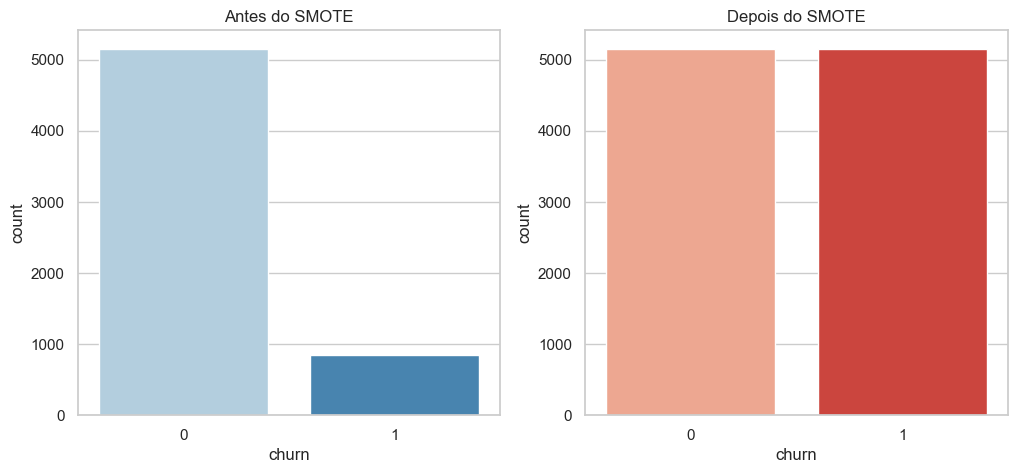


✅ SUCESSO: Arquivo 'churn_refinado.csv' gerado com 10314 linhas.
Local: C:\Users\Luca\Documents\git hub\3° Periodo\Data Mining e Graph Mining\regressão-logistica\churn_refinado.csv


In [ ]:
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# Verificação da proporção atual
print("--- Proporção ANTES do SMOTE ---")
print(df_final_step5['churn'].value_counts())
print(df_final_step5['churn'].value_counts(normalize=True) * 100)

# Aplicação do SMOTE - O SMOTE cria exemplos sintéticos da classe minoritária (Churn = 1)
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(df_final_step5.drop('churn', axis=1), df_final_step5['churn'])

# Criando o DataFrame Refinado
df_refinado = pd.DataFrame(X_res, columns=df_final_step5.drop('churn', axis=1).columns)
df_refinado['churn'] = y_res

# Verificação da proporção depois
print("\n--- Proporção DEPOIS do SMOTE ---")
print(df_refinado['churn'].value_counts())
print(df_refinado['churn'].value_counts(normalize=True) * 100)

# Visualização Comparativa 
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x='churn', data=df_final_step5, ax=ax[0], palette='Blues')
ax[0].set_title('Antes do SMOTE')

sns.countplot(x='churn', data=df_refinado, ax=ax[1], palette='Reds')
ax[1].set_title('Depois do SMOTE')

plt.savefig(os.path.join(path_graficos, '05_comparativo_balanceamento.png'))
plt.show()


output_path = r'C:\Users\Luca\Documents\git hub\3° Periodo\Data Mining e Graph Mining\churn-prediction-data-mining\churn_refinado.csv'
df_refinado.to_csv(output_path, index=False)

print(f"\n Arquivo 'churn_refinado.csv' gerado com {df_refinado.shape[0]} linhas.")
print(f"Local: {output_path}")

# Relatório de Preparação de dados

In [1]:
import os
from datetime import datetime

path_relatorios = r'C:\Users\Luca\Documents\git hub\3° Periodo\Data Mining e Graph Mining\churn-prediction-data-mining\Relatorios'

conteudo_prep = f"""# Relatório de Lógica de Preparação de Dados
**Data de Geração:** {datetime.now().strftime('%d/%m/%Y %H:%M:%S')}
**Projeto:** Previsão de Churn - Telecom

## 1. Tratamento de Dados Ausentes
Identificamos lacunas em `total_charges` e `avg_download_mbps`. Optamos pela **Imputação via Mediana** por ser uma medida de tendência central robusta a outliers, comum em dados de faturamento.

## 2. Limpeza e Padronização
Os nomes das colunas foram convertidos para *snake_case* para facilitar a manipulação via código. A coluna `customer_id` foi removida por ser um identificador único sem valor estatístico.

## 3. Análise Exploratória (EDA)
Abaixo, as visualizações que fundamentaram as decisões de engenharia:

![Distribuição Target](../graficos_preparation_csv/01_distribuicao_churn.png)
![Matriz de Correlação](../graficos_preparation_csv/02_matriz_correlacao.png)
![Boxplots Separabilidade](../graficos_preparation_csv/03_boxplots_separabilidade.png)
![Densidade Tenure](../graficos_preparation_csv/04_densidade_tenure.png)

## 4. Engenharia de Atributos
Criamos variáveis para capturar o "comportamento de risco":
- `newbie_at_risk`: Clientes novos sem contrato de fidelidade.
- `financial_instability_score`: Soma de atrasos e métodos de pagamento instáveis.
- `log_total_charges`: Normalização da escala de gastos.

## 5. Seleção de Atributos
Aplicamos **Lasso (Regularização L1)** e **Mutual Information**. O Lasso eliminou variáveis colineares, reduzindo o ruído e prevenindo o overfitting, resultando em 22 atributos finais.

## 6. Tratamento de Desbalanceamento (SMOTE)
O dataset original era altamente desbalanceado (85/15). Utilizamos o **SMOTE** para criar amostras sintéticas da classe minoritária, permitindo que o modelo aprenda o padrão de Churn com a mesma importância da permanência.

![Comparativo Balanceamento](../graficos_preparation_csv/05_comparativo_balanceamento.png)

---
**Arquivo de Saída:** `churn_refinado.csv`
"""

with open(os.path.join(path_relatorios, 'relatorio_logica-de-preparacao.md'), 'w', encoding='utf-8') as f:
    f.write(conteudo_prep)

print(" Relatório de Preparação gerado com caminhos ../ e explicações detalhadas.")

 Relatório de Preparação gerado com caminhos ../ e explicações detalhadas.
